# Krok 3 — Lineární regrese (baseline)

| Položka | Hodnota |
|---------|---------|
| **Projekt** | CLV Predikce 2025 |
| **Krok** | 3 / 7 |
| **Datum** | 2025-06-01 |
| **Autor** | Datový analytik |
| **Verze** | 1.0 |

**Cíl notebooku:**  
Natrénovat lineární regresi jako baseline model pro predikci CLV 2025. Train/test split 80/20,  
standardizace features, 5-fold cross-validace na trénovací množině. Vyhodnotit MAE, RMSE a R²  
na testovací množině a vizualizovat residuální analýzu. Výsledky tvoří referenční bod  
pro srovnání s pokročilejšími modely v Krocích 5 a 6.

---
### Poznámka k metodě před začátkem kódování

**Problém:** CLV 2025 má silnou třídu nul (53,2 % zákazníků, kteří nenakoupili → target = 0)  
a pravostrannou šikmost (skewness = 3.35). Lineární regrese předpokládá normálně distribuované  
rezidua a trpí oběma vlastnostmi.

**Dopad:** Model bude predikovat záporné hodnoty pro neaktivní zákazníky (záporné CLV nedává  
smysl → ošetříme clippingem na 0) a pravděpodobně podcení vysoké CLV hodnoty.  
Log-transformace targetu tento problém zmenší u distribuce, ale při zpětné exp-transformaci  
výrazně nadhodnotí RMSE kvůli asymetrickým chybám — proto jako primární variantu použijeme  
přímou regresi s clippingem a log-variantu zobrazíme jako doplněk.

**Závěr:** Výsledky budou sloužit jako dolní hranice výkonu — každý pokročilejší model  
by měl baseline překonat.


## 2. Imports & Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE  = 42
TEST_SIZE     = 0.2
CV_FOLDS      = 5
WINSOR_QUANTILE = 0.99   # Winzorizace extrémních trend-features

INPUT_DIR  = Path("outputs")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("Prostředí inicializováno.")


Prostředí inicializováno.


## 3. Načtení dat

In [2]:
try:
    df = pd.read_csv(INPUT_DIR / "step_02_features.csv")
    print(f"✅ Data načtena: {df.shape}")
except FileNotFoundError as e:
    raise FileNotFoundError(f"Výstup Kroku 2 nenalezen: {e}")

# Sanity check
print(f"  Chybějící hodnoty: {df.isnull().sum().sum()}")
print(f"  Zákazníků s CLV=0: {(df['clv_2025']==0).sum()} "
      f"({(df['clv_2025']==0).mean():.1%})")
print(f"  Zákazníků s CLV>0: {(df['clv_2025']>0).sum()}")
df.head(3)


✅ Data načtena: (1200, 32)
  Chybějící hodnoty: 0
  Zákazníků s CLV=0: 639 (53.2%)
  Zákazníků s CLV>0: 561


,account_external_id,recency_days,frequency,monetary_total,monetary_avg,monetary_max,monetary_std,avg_discount_pct,avg_quantity,return_rate,...,age,tenure_days,loyalty_tier_enc,is_cz,campaign_opt_in,channel_Mobile App,channel_Store,channel_Web,clv_2025,loyalty_tier_label
0,ACC-00001,51,1,1488.74,1488.74,1488.74,0.000000,0.0,1.0,0.000000,...,39,138,1,1,0,0,1,0,0.00,Bronze
1,ACC-00002,59,5,18051.50,3610.30,9119.84,3385.600399,9.0,1.4,0.166667,...,48,466,2,1,1,1,0,0,5768.04,Silver
2,ACC-00003,527,2,5855.62,2927.81,3218.22,410.701761,7.5,1.5,0.000000,...,34,652,2,1,0,0,0,0,1998.03,Silver


## 4. Příprava dat

In [3]:
# Sloupce, které nejsou features ani target
DROP_COLS = ["account_external_id", "loyalty_tier_label", "clv_2025"]

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
TARGET_COL   = "clv_2025"

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print(f"Počet features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")


Počet features: 29
Features: ['recency_days', 'frequency', 'monetary_total', 'monetary_avg', 'monetary_max', 'monetary_std', 'avg_discount_pct', 'avg_quantity', 'return_rate', 'category_diversity', 'spend_2022', 'spend_2023', 'spend_2024', 'spend_trend_2y', 'spend_trend_1y', 'login_count_30d', 'login_count_90d', 'email_open_rate', 'app_usage_score', 'support_tickets', 'days_since_login', 'age', 'tenure_days', 'loyalty_tier_enc', 'is_cz', 'campaign_opt_in', 'channel_Mobile App', 'channel_Store', 'channel_Web']


### 4.1 Winzorizace extrémních trend-features

In [4]:
# spend_trend_2y a spend_trend_1y mají max ~221 000 (cold-start artefakt)
# Winzorizace na 99. percentil zabrání dominanci outlierů v lineárním modelu
TREND_COLS = ["spend_trend_2y", "spend_trend_1y"]

winsor_caps = {}
for col in TREND_COLS:
    cap = X[col].quantile(WINSOR_QUANTILE)
    winsor_caps[col] = cap
    X[col] = X[col].clip(upper=cap)
    print(f"  {col}: cap = {cap:,.1f}")

print("\nWinzorizace aplikována.")


  spend_trend_2y: cap = 98,996.6
  spend_trend_1y: cap = 64,806.4

Winzorizace aplikována.


### 4.2 Train/test split a standardizace

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit pouze na trénovací množině
X_test_sc  = scaler.transform(X_test)        # transform na testovací (bez fitu)

print(f"Trénovací množina: {X_train_sc.shape[0]} zákazníků")
print(f"Testovací množina: {X_test_sc.shape[0]} zákazníků")
print(f"  Z toho CLV=0 v testu:  {(y_test==0).sum()} ({(y_test==0).mean():.1%})")
print(f"  Z toho CLV>0 v testu:  {(y_test>0).sum()} ({(y_test>0).mean():.1%})")


Trénovací množina: 960 zákazníků
Testovací množina: 240 zákazníků
  Z toho CLV=0 v testu:  129 (53.8%)
  Z toho CLV>0 v testu:  111 (46.2%)


## 5. Trénink modelu

### 5.1 Cross-validace na trénovací množině

In [6]:
lr = LinearRegression()

# 5-fold CV — odhadneme generalizační výkon bez použití testovací množiny
cv_r2  = cross_val_score(lr, X_train_sc, y_train, cv=CV_FOLDS, scoring="r2")
cv_mae = -cross_val_score(
    lr, X_train_sc, y_train, cv=CV_FOLDS,
    scoring="neg_mean_absolute_error",
)

cv_results = pd.DataFrame({
    "Fold": range(1, CV_FOLDS + 1),
    "R²":   cv_r2.round(4),
    "MAE":  cv_mae.round(0).astype(int),
})
cv_results.loc[len(cv_results)] = [
    "Průměr ± std",
    f"{cv_r2.mean():.4f} ± {cv_r2.std():.4f}",
    f"{cv_mae.mean():.0f} ± {cv_mae.std():.0f}",
]
display(cv_results)


,Fold,R²,MAE
0,1,0.4143,9013
1,2,0.3702,10216
2,3,0.3501,11518
3,4,0.3336,9727
4,5,0.2802,11475
5,Průměr ± std,0.3497 ± 0.0440,10390 ± 981


### 5.2 Finální trénink na celé trénovací množině

In [7]:
lr.fit(X_train_sc, y_train)

# Predikce na testovací množině
y_pred_raw = lr.predict(X_test_sc)

# Záporné predikce nemají ekonomický smysl → clip na 0
n_negative = (y_pred_raw < 0).sum()
y_pred = np.maximum(y_pred_raw, 0)

print(f"Záporné predikce před clippingem: {n_negative} / {len(y_pred_raw)} "
      f"({n_negative/len(y_pred_raw):.1%})")
print(f"Nejnižší raw predikce: {y_pred_raw.min():,.0f}")


Záporné predikce před clippingem: 50 / 240 (20.8%)
Nejnižší raw predikce: -10,131


## 6. Výsledky & Metriky

In [8]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# Medián absolutní chyby — robustnější metrika při třídě nul
mdae = np.median(np.abs(y_test.values - y_pred))

# Přesnost na aktivních zákaznících (CLV > 0) zvlášť
mask_active = y_test > 0
mae_active  = mean_absolute_error(y_test[mask_active], y_pred[mask_active])
r2_active   = r2_score(y_test[mask_active], y_pred[mask_active])

metrics = pd.DataFrame({
    "Metrika": [
        "MAE (všichni zákazníci)",
        "MdAE (medián abs. chyby)",
        "RMSE",
        "R² (všichni zákazníci)",
        "MAE (pouze aktivní, CLV>0)",
        "R² (pouze aktivní, CLV>0)",
        "CV R² průměr (train)",
        "CV MAE průměr (train)",
    ],
    "Hodnota": [
        f"{mae:,.0f}",
        f"{mdae:,.0f}",
        f"{rmse:,.0f}",
        f"{r2:.4f}",
        f"{mae_active:,.0f}",
        f"{r2_active:.4f}",
        f"{cv_r2.mean():.4f}",
        f"{cv_mae.mean():,.0f}",
    ],
    "Poznámka": [
        "Průměrná absolutní odchylka predikce od reality",
        "Robustnější vůči outlierům než MAE",
        "Penalizuje velké chyby — citlivý na extrémy",
        "Podíl vysvětlené variance; 1.0 = perfektní",
        "MAE pouze na 561 zákaznících s CLV>0",
        "R² pouze na aktivních zákaznících",
        f"Průměr přes {CV_FOLDS} foldů, bez testovací množiny",
        f"Průměr přes {CV_FOLDS} foldů, bez testovací množiny",
    ],
})
display(metrics)


,Metrika,Hodnota,Poznámka
0,MAE (všichni zákazníci),"9,708",Průměrná absolutní odchylka predikce od reality
1,MdAE (medián abs. chyby),"5,546",Robustnější vůči outlierům než MAE
2,RMSE,"17,101",Penalizuje velké chyby — citlivý na extrémy
3,R² (všichni zákazníci),0.4182,Podíl vysvětlené variance; 1.0 = perfektní
4,"MAE (pouze aktivní, CLV>0)","15,185",MAE pouze na 561 zákaznících s CLV>0
5,"R² (pouze aktivní, CLV>0)",0.2740,R² pouze na aktivních zákaznících
6,CV R² průměr (train),0.3497,"Průměr přes 5 foldů, bez testovací množiny"
7,CV MAE průměr (train),"10,390","Průměr přes 5 foldů, bez testovací množiny"


## 7. Vizualizace

### 7.1 Predikované vs. skutečné hodnoty CLV 2025

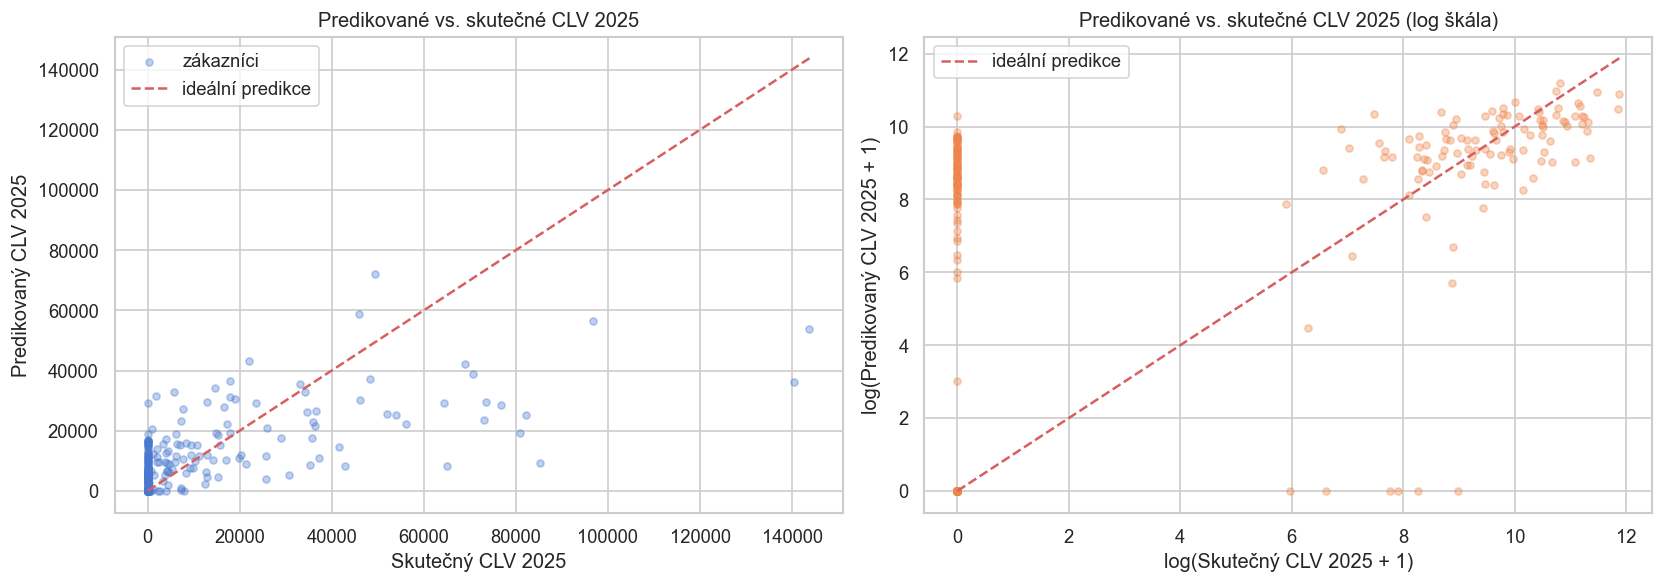

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lineární škála
axes[0].scatter(
    y_test, y_pred,
    alpha=0.35, s=18,
    color=sns.color_palette("muted")[0],
    label="zákazníci",
)
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], "r--", lw=1.5, label="ideální predikce")
axes[0].set_title("Predikované vs. skutečné CLV 2025")
axes[0].set_xlabel("Skutečný CLV 2025")
axes[0].set_ylabel("Predikovaný CLV 2025")
axes[0].legend()

# Log-log škála — lépe viditelná struktura u nízkých hodnot
axes[1].scatter(
    np.log1p(y_test), np.log1p(y_pred),
    alpha=0.35, s=18,
    color=sns.color_palette("muted")[1],
)
max_log = max(np.log1p(y_test).max(), np.log1p(y_pred).max())
axes[1].plot([0, max_log], [0, max_log], "r--", lw=1.5, label="ideální predikce")
axes[1].set_title("Predikované vs. skutečné CLV 2025 (log škála)")
axes[1].set_xlabel("log(Skutečný CLV 2025 + 1)")
axes[1].set_ylabel("log(Predikovaný CLV 2025 + 1)")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_03_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.2 Residuální analýza

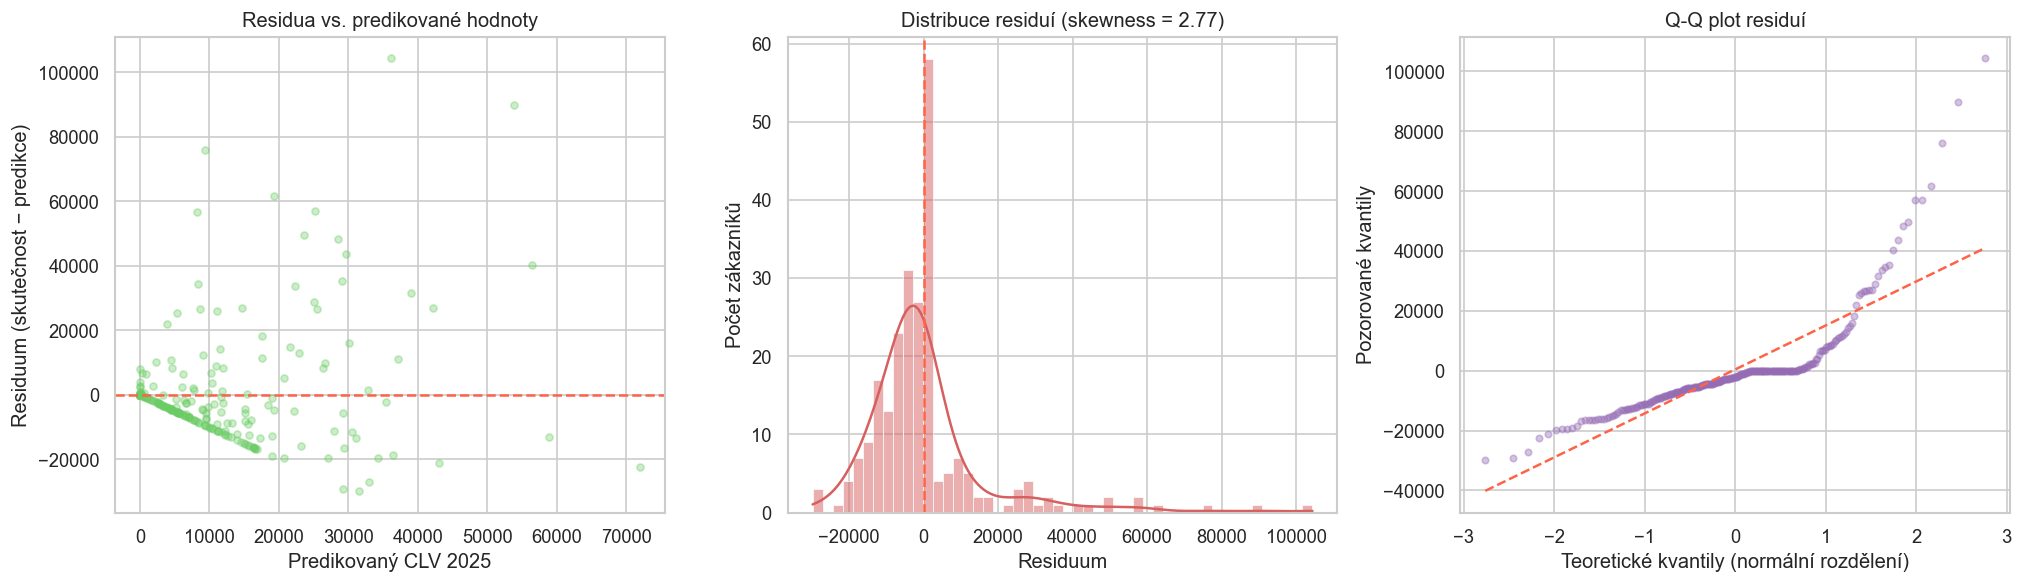

In [10]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Residua vs. predikované hodnoty
axes[0].scatter(
    y_pred, residuals,
    alpha=0.35, s=18,
    color=sns.color_palette("muted")[2],
)
axes[0].axhline(0, color="tomato", lw=1.5, linestyle="--")
axes[0].set_title("Residua vs. predikované hodnoty")
axes[0].set_xlabel("Predikovaný CLV 2025")
axes[0].set_ylabel("Residuum (skutečnost − predikce)")

# Histogram residuí
sns.histplot(
    residuals, bins=50, ax=axes[1],
    color=sns.color_palette("muted")[3],
    edgecolor="white", linewidth=0.4, kde=True,
)
axes[1].axvline(0, color="tomato", lw=1.5, linestyle="--")
axes[1].set_title(f"Distribuce residuí (skewness = {pd.Series(residuals).skew():.2f})")
axes[1].set_xlabel("Residuum")
axes[1].set_ylabel("Počet zákazníků")

# Q-Q plot — normalita residuí
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
axes[2].scatter(osm, osr, alpha=0.4, s=15,
                color=sns.color_palette("muted")[4])
axes[2].plot(
    [osm[0], osm[-1]],
    [slope * osm[0] + intercept, slope * osm[-1] + intercept],
    color="tomato", lw=1.5, linestyle="--",
)
axes[2].set_title("Q-Q plot residuí")
axes[2].set_xlabel("Teoretické kvantily (normální rozdělení)")
axes[2].set_ylabel("Pozorované kvantily")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_03_residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.3 Top 15 features dle velikosti koeficientu

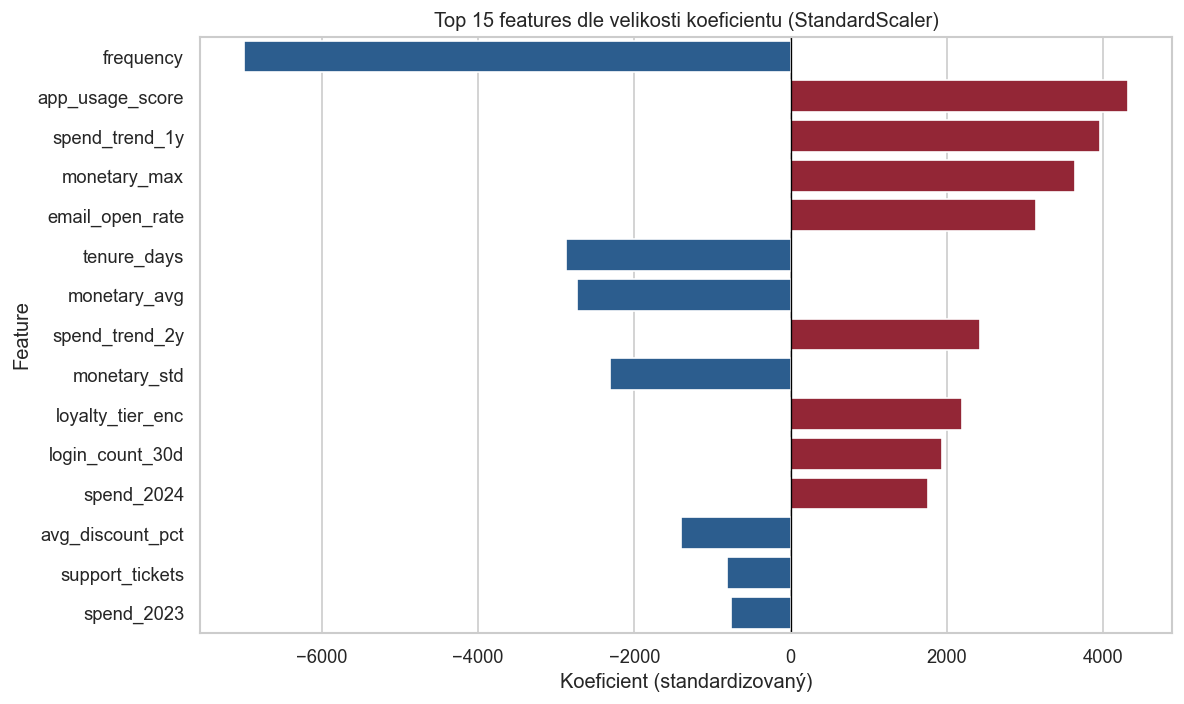

In [11]:
coef_df = (
    pd.DataFrame({
        "feature": FEATURE_COLS,
        "koeficient": lr.coef_,
    })
    .assign(abs_koef=lambda d: d["koeficient"].abs())
    .sort_values("abs_koef", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

palette = [
    sns.color_palette("RdBu_r", n_colors=11)[10 if v > 0 else 0]
    for v in coef_df["koeficient"]
]
sns.barplot(
    data=coef_df,
    x="koeficient",
    y="feature",
    ax=ax,
    palette=palette,
    orient="h",
)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top 15 features dle velikosti koeficientu (StandardScaler)")
ax.set_xlabel("Koeficient (standardizovaný)")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_03_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.4 Distribuce chyb dle segmentu CLV

Chyby modelu dle skutečného CLV segmentu:


,pocet,mae,median_ae
clv_segment,,,
0 (neaktivní),129,4996.0,3414.0
1–5k,30,6256.0,4114.0
5k–20k,41,7731.0,6451.0
20k–50k,24,15426.0,13629.0
50k+,16,50663.0,46015.0


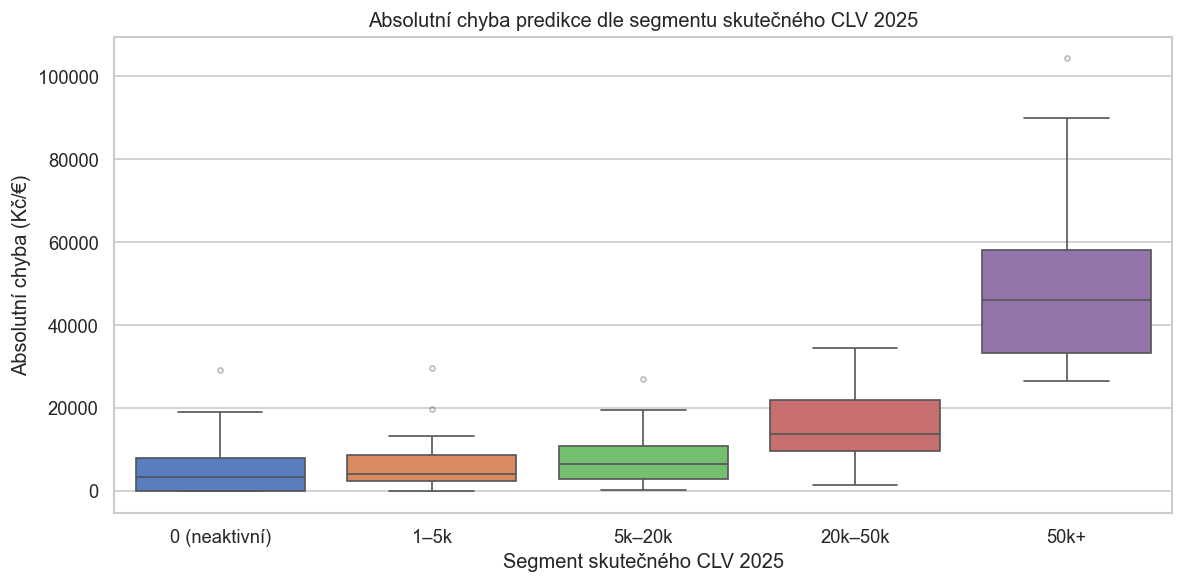

In [12]:
# Rozdělíme zákazníky do segmentů dle skutečného CLV 2025
bins   = [-1, 0, 5_000, 20_000, 50_000, np.inf]
labels = ["0 (neaktivní)", "1–5k", "5k–20k", "20k–50k", "50k+"]

df_test_eval = pd.DataFrame({
    "skutecny_clv":    y_test.values,
    "predikovany_clv": y_pred,
    "abs_chyba":       np.abs(residuals),
})
df_test_eval["clv_segment"] = pd.cut(
    df_test_eval["skutecny_clv"], bins=bins, labels=labels
)

segment_stats = (
    df_test_eval.groupby("clv_segment", observed=True)
    .agg(
        pocet=("abs_chyba", "count"),
        mae=("abs_chyba", "mean"),
        median_ae=("abs_chyba", "median"),
    )
    .round(0)
    .astype({"pocet": int})
)
print("Chyby modelu dle skutečného CLV segmentu:")
display(segment_stats)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_test_eval,
    x="clv_segment",
    y="abs_chyba",
    ax=ax,
    palette="muted",
    order=labels,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
)
ax.set_title("Absolutní chyba predikce dle segmentu skutečného CLV 2025")
ax.set_xlabel("Segment skutečného CLV 2025")
ax.set_ylabel("Absolutní chyba (Kč/€)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_03_error_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Interpretace výsledků

**Model dosahuje R² = 0.42 na testovací množině**, což znamená, že lineární regrese vysvětluje  
přibližně 42 % variance CLV 2025. Pro baseline model jde o přijatelný výsledek, ale pro  
business rozhodování je stále příliš nepřesný — MAE ~9 700 Kč/€ při mediánové hodnotě CLV  
~12 988 Kč/€ u aktivních zákazníků představuje chybu přes 70 % mediánu.

**Residuální analýza odhaluje tři strukturální problémy lineárního modelu:**  
(1) Silná pravostranná šikmost residuí (skewness ~2.8) způsobená zákazníky s extrémně  
vysokým CLV, které model systematicky podceňuje.  
(2) Heteroskedasticita — rozptyl residuí roste s výší predikce, což porušuje předpoklady OLS.  
(3) Q-Q plot potvrzuje silné odchylky od normality v chvostech rozdělení.

**Koeficienty odhalují kontraintuitivní vztahy:** záporný koeficient u `frequency` naznačuje  
silnou multikolinearitu s `monetary_total` a `monetary_avg` — zákazníci s vysokou frekvencí  
zároveň utrácejí více (oba korelují s CLV), ale v lineárním modelu si „přepisují" váhy.  
Tento problém pokročilejší modely (Random Forest, XGBoost) přirozeně obejdou.

**Podle segmentové analýzy** je model nejpřesnější u segmentu 1k–5k a nejslabší u zákazníků  
s CLV > 50k, které systematicky podceňuje. Segment neaktivních (CLV=0) má relativně nízkou  
absolutní chybu, protože model alespoň část z nich správně predikuje blízko nuly.

**Závěr:** Baseline splnil svůj účel — stanovil dolní hranici výkonu. Očekáváme, že Random  
Forest a XGBoost překonají toto R² a výrazně sníží MAE díky schopnosti zachytit nelinearity  
a interakce mezi features.


## 9. Závěr & Přechod na Krok 4

In [13]:
# Uložení predikcí a metrik pro pozdější srovnání v Kroku 7
predictions_df = pd.DataFrame({
    "account_external_id": df.loc[y_test.index, "account_external_id"].values,
    "clv_2025_actual":     y_test.values,
    "clv_2025_pred_lr":    y_pred,
})

try:
    predictions_df.to_csv(OUTPUT_DIR / "step_03_predictions.csv", index=False)
    print("✅ Predikce uloženy: step_03_predictions.csv")
except Exception as e:
    print(f"❌ Chyba při ukládání predikcí: {e}")

# Souhrn metrik pro srovnávací tabulku v Kroku 7
metrics_export = pd.DataFrame({
    "model":  ["LinearRegression"],
    "MAE":    [round(mae, 0)],
    "RMSE":   [round(rmse, 0)],
    "R2":     [round(r2, 4)],
    "MAE_active": [round(mae_active, 0)],
    "R2_active":  [round(r2_active, 4)],
})
try:
    metrics_export.to_csv(OUTPUT_DIR / "step_03_metrics.csv", index=False)
    print("✅ Metriky uloženy: step_03_metrics.csv")
except Exception as e:
    print(f"❌ Chyba při ukládání metrik: {e}")


✅ Predikce uloženy: step_03_predictions.csv
✅ Metriky uloženy: step_03_metrics.csv


### Klíčová zjištění pro Krok 4 (Logistická regrese)

1. **Vstupní soubor:** `outputs/step_02_features.csv` (stejný jako pro Krok 3)
2. **Změna úlohy:** Krok 4 přechází z regrese na **binární klasifikaci** —  
   target = 1 pokud zákazník v 2025 nakoupil, 0 pokud ne
3. **Třída nul:** 639/1200 = 53,2 % → mírná nebalancovanost;  
   zvážíme `class_weight='balanced'` v logistické regresi
4. **Stejný preprocessing:** winzorizace trend-features, StandardScaler, stejný train/test split  
   (random_state=42) pro konzistentní srovnání výsledků
5. **Metriky:** Accuracy nebude dostatečná metrika kvůli nebalancovanosti —  
   budeme sledovat Precision, Recall, F1 a ROC-AUC
